In [113]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [114]:
P = 100e-3
w0 = 1e-6
Intensity = 2*P/(pi*w0**2)
e_delta = (3*pi*c**2)/(2*omega_res[0]**3) * linewidths[0]/(omega_tweezer - omega_res[0]) * Intensity + (3*pi*c**2)/(2*omega_res[1]**3) * linewidths[1]/(omega_tweezer - omega_res[1]) * Intensity
print(((e_delta / hbar)/(2*pi))*1e-6,"Stark Shift in MHz")

-87.8353196847003 Stark Shift in MHz


# Parallel optimization, tweezed vs untweezed with defined functions, not optimized power

In [64]:
N_max = 6  # Change this to run for higher N values
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 125e3

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}


results_test_check = []
for Ni in range(2, N_max + 1):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

print(f_rf_r, f_rf_a)
for Ni in range(2, N_max + 1):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i - 2][1][0][2] for i in range(2, N_max + 1)]

3000000.0 125000.0


In [115]:
N_max = 10  # Change this to run for higher N values
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 125e3

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}

In [65]:
N_max = 10  # Change this to run for higher N values
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 125e3

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}


results_test_check_test = []
for Ni in range(2, N_max):
    print(f"tweezed: N = {Ni}")
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check_test.append((Ni, winners))

untweezed_results_test = []

print(f_rf_r, f_rf_a)
for Ni in range(2, N_max):
    print(f"untweezed: N = {Ni}")
    winners = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results_test.append((Ni, winners))

untweezed_winners_test = [untweezed_results_test[i - 2][1][0][2] for i in range(2, N_max)]

tweezed: N = 2
tweezed: N = 3
tweezed: N = 4
tweezed: N = 5
tweezed: N = 6
tweezed: N = 7
tweezed: N = 8
tweezed: N = 9
3000000.0 125000.0
untweezed: N = 2
untweezed: N = 3
untweezed: N = 4
untweezed: N = 5
untweezed: N = 6
untweezed: N = 7
untweezed: N = 8
untweezed: N = 9


In [66]:
untweezed_winners == untweezed_winners_test

False

In [67]:
results_test_check_test == results_test_check

False

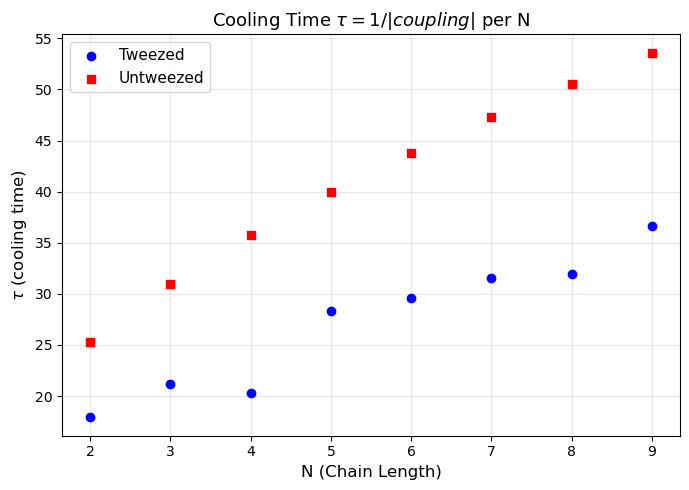

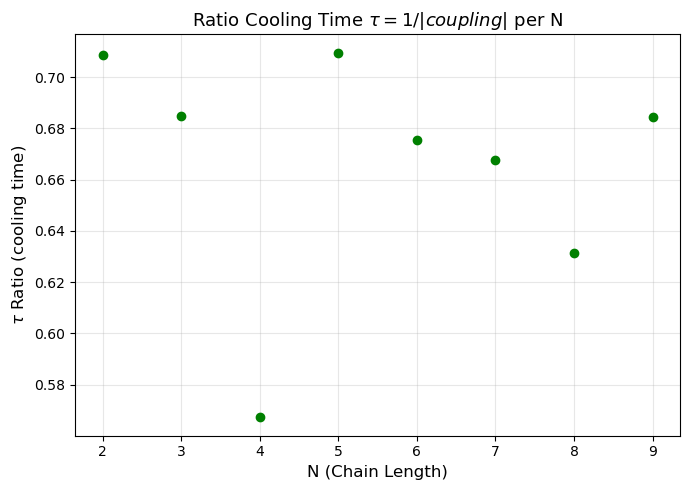

In [68]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check_test:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores ---
untweezed_data_test = {}  # {N: score}

for N_val, winners in untweezed_results_test:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data_test[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data_test.keys())
scores_untweezed = [untweezed_data_test[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power sweep

In [133]:
N_max

10

In [126]:
N_values = np.arange(2, N_max)
w0 = 1e-6
P_list = np.linspace(1e-6, 10, 200)  # optical powers from 10 mW to 1 W

f_rf_r = 3e6
f_rf_a = 1e6
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}

# --- Run power sweep using your tweezed-only function ---
power_results = [[] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only_test(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            ueq,
            P,
            w0,
            max_tweezed=1,
        )
        power_results[N - 2].append(winners)

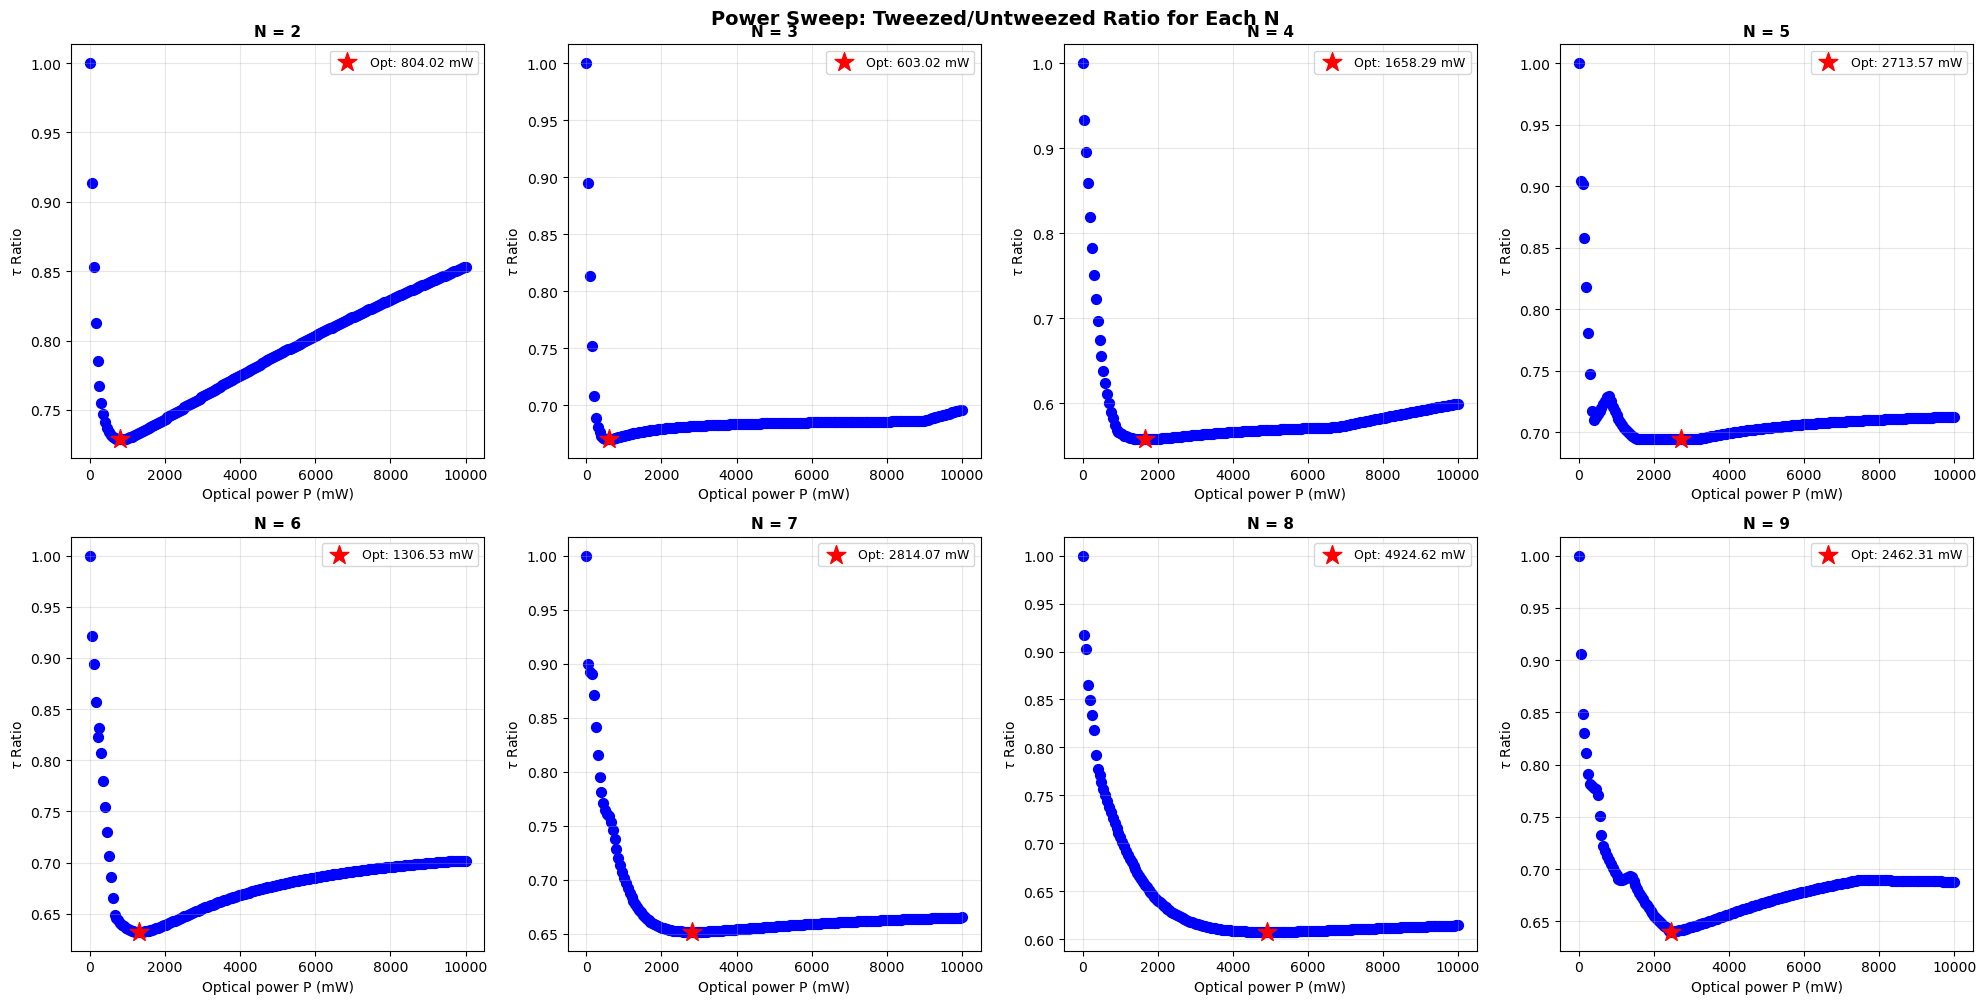


Optimal Powers Summary:
N = 2: P_opt = 8.040210e-01 W = 804.0210 mW,  Ratio = 0.7287
N = 3: P_opt = 6.030160e-01 W = 603.0160 mW,  Ratio = 0.6699
N = 4: P_opt = 1.658292e+00 W = 1658.2923 mW,  Ratio = 0.5578
N = 5: P_opt = 2.713569e+00 W = 2713.5686 mW,  Ratio = 0.6944
N = 6: P_opt = 1.306534e+00 W = 1306.5335 mW,  Ratio = 0.6322
N = 7: P_opt = 2.814071e+00 W = 2814.0711 mW,  Ratio = 0.6517
N = 8: P_opt = 4.924624e+00 W = 4924.6236 mW,  Ratio = 0.6076
N = 9: P_opt = 2.462312e+00 W = 2462.3123 mW,  Ratio = 0.6398


In [127]:
# --- Extract and plot for each N ---
n_panels = N_max - 2  # number of N values = range(2, N_max)
ncols = 4
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

f_rf_r = 3e6
f_rf_a = 1e6
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}

untweezed_results_local = []
for Ni in range(2, N_max):
    winners = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results_local.append((Ni, winners))

untweezed_winners_local = [abs(untweezed_results_local[i - 2][1][0][2]) for i in range(2, N_max)]

for idx, N in enumerate(range(2, N_max)):
    x_tweezed = []
    y_tweezed = []

    for P_val, winners in zip(P_list, power_results[N - 2]):
        if not winners:
            continue
        winner = winners[0]

        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue

        if tweezed_ion is None:
            continue

        x_tweezed.append(P_val)
        y_tweezed.append(abs(score))

    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)

    untweezed_ref = untweezed_winners_local[N - 2]

    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)

        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]

        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)

        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].scatter(
            opt_power_mW, opt_ratio,
            color='red', s=200, marker='*', zorder=5,
            label=f'Opt: {opt_power_mW:.2f} mW',
        )
        axes[idx].legend(fontsize=9)

# Hide unused panels
for ax in axes[n_panels:]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle(
    "Power Sweep: Tweezed/Untweezed Ratio for Each N",
    fontsize=14, fontweight='bold', y=1.00,
)
plt.show()

optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(range(2, N_max), optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

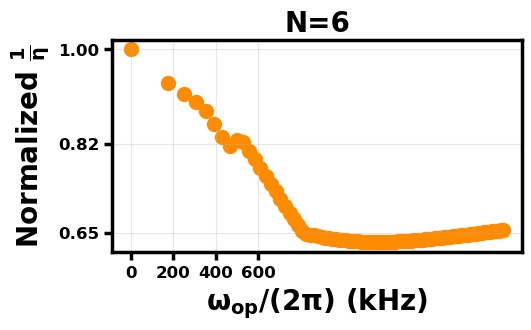


Optimal Power for N = 6:
P_opt = 1.303031e+00 W = 1303.0309 mW
Ratio = 0.6322


In [128]:
# Plot power sweep for N=6 alone
f_rf_r = 3e6
f_rf_a = 1e6

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}
N = 6
w0 = 1e-6
P_list = np.linspace(1e-6, 3, 100)  # optical powers

# Run power sweep for N=6
power_results_N6 = []
tweezer_freqs_results_N6 = []
for P in P_list:
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P,
        w0,
        max_tweezed=1,
    )
    # x axis as tweezer frequency instead:
    tweezer_freqs = omega_tweezer_r(potential(omega_tweezer, linewidths, omega_res, P, w0), w0, m)
    tweezer_freqs_results_N6.append(tweezer_freqs)
    power_results_N6.append(winners)

# Get untweezed reference for N=6
untweezed_winners_N6 = untweezed_winners_test[N - 2]

# Extract data
x_tweezed = []
y_tweezed = []

for P_val, winners in zip(P_list, power_results_N6):
    if not winners:
        continue
    winner = winners[0]

    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue

    if tweezed_ion is None:
        continue

    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# Calculate ratio
ratio = untweezed_winners_N6 / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]

# Plot
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(520 * px, 319 * px), layout='constrained')
ax.scatter(
    np.array(tweezer_freqs_results_N6) / (2.0 * pi * 1e3),  # Convert to kHz
    ratio,
    marker='o',
    color='#FF8C00',
    s=100,
    label='Ratio across power',
)
ax.set_xlabel("$\mathbf{\omega_{op}/(2\pi)}$ (kHz)", fontsize=20, fontweight='bold')
ax.set_ylabel(r"Normalized $\mathbf{\frac{1}{\eta}}$", fontsize=20, fontweight='bold')
ax.set_title(f"N=6", fontsize=20, fontweight='bold')
ax.set_xticks([0, 200, 400, 600])
ax.set_yticks([0.65, 0.82, 1.0])
ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.grid(True, alpha=0.3)

plt.show()

print(f"\nOptimal Power for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)

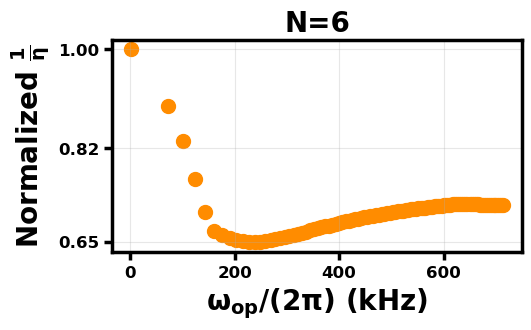


Optimal Power for N = 6:
P_opt = 5.555644e-02 W = 55.5564 mW
Ratio = 0.6495


In [129]:
# Plot power sweep for N=6 alone

N = 6
w0 = 1e-6
P_list = np.linspace(1e-6, 0.5, 100)  # optical powers
f_rf_r = 3e6
f_rf_a = 200e3

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}
# Run power sweep for N=6
power_results_N6 = []
tweezer_freqs_results_N6 = []
for P in P_list:
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P,
        w0,
        max_tweezed=1,
    )
    # x axis as tweezer frequency instead:
    tweezer_freqs = omega_tweezer_r(potential(omega_tweezer, linewidths, omega_res, P, w0), w0, m)
    tweezer_freqs_results_N6.append(tweezer_freqs)
    power_results_N6.append(winners)

# Get untweezed reference for N=6
untweezed_winners_N6 = untweezed_winners_test[N - 2]

# Extract data
x_tweezed = []
y_tweezed = []

for P_val, winners in zip(P_list, power_results_N6):
    if not winners:
        continue
    winner = winners[0]

    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue

    if tweezed_ion is None:
        continue

    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# Calculate ratio
ratio = untweezed_winners_N6 / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]

# Plot
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(520 * px, 319 * px), layout='constrained')
ax.scatter(
    np.array(tweezer_freqs_results_N6) / (2.0 * pi * 1e3),  # Convert to kHz
    ratio,
    marker='o',
    color='#FF8C00',
    s=100,
    label='Ratio across power',
)
ax.set_xlabel("$\mathbf{\omega_{op}/(2\pi)}$ (kHz)", fontsize=20, fontweight='bold')
ax.set_ylabel(r"Normalized $\mathbf{\frac{1}{\eta}}$", fontsize=20, fontweight='bold')
ax.set_title(f"N=6", fontsize=20, fontweight='bold')
ax.set_xticks([0, 200, 400, 600])
ax.set_yticks([0.65, 0.82, 1.0])
ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.grid(True, alpha=0.3)

plt.show()

print(f"\nOptimal Power for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)

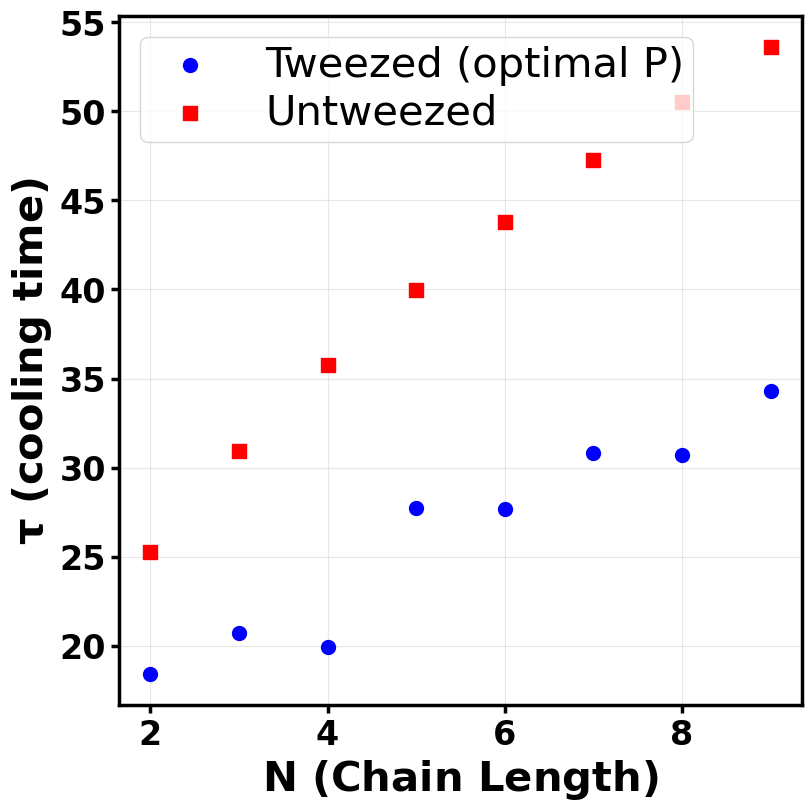

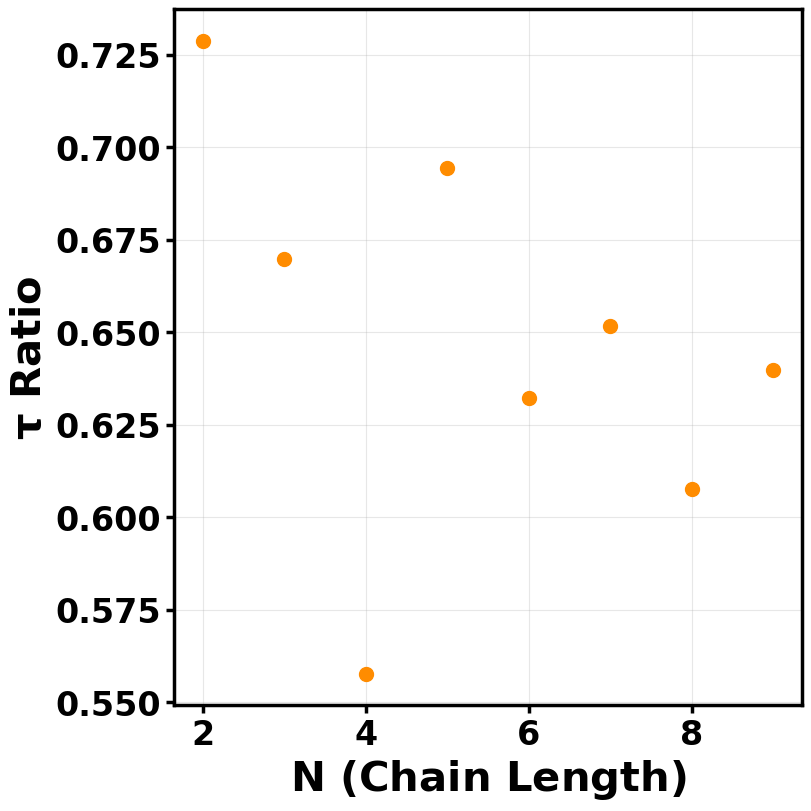

In [134]:
# --- Plot tau comparison at optimal powers from the power sweep ---
N_values_plot = list(range(2, N_max+2))

# Guard against partial runs (e.g. power sweep errored partway through)
n = min(len(N_values_plot), len(untweezed_winners_local), len(optimal_ratios))
N_values_plot = N_values_plot[:n]
uw = np.array(untweezed_winners_local[:n])
opt_r = np.array(optimal_ratios[:n])

tau_untweezed_opt = 1.0 / uw
tau_tweezed_opt = opt_r * tau_untweezed_opt

px = 1 / plt.rcParams['figure.dpi']

def style_ax(ax):
    ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=24)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    ax.grid(True, alpha=0.3)

# --- Plot 1: absolute tau values ---
fig, ax = plt.subplots(figsize=(800 * px, 800 * px), layout='constrained')
ax.scatter(N_values_plot, tau_tweezed_opt, marker='o', color='blue', s=100,
           label='Tweezed (optimal P)', zorder=3)
ax.scatter(N_values_plot, tau_untweezed_opt, marker='s', color='red', s=100,
           label='Untweezed', zorder=3)
ax.set_xlabel(r'$\mathbf{N}$ (Chain Length)', fontsize=30, fontweight='bold')
ax.set_ylabel(r'$\mathbf{\tau}$ (cooling time)', fontsize=30, fontweight='bold')
ax.legend(fontsize=30, borderpad=0.2, labelspacing=0.2)
style_ax(ax)
plt.show()

# --- Plot 2: tau ratio at optimal power ---
fig, ax = plt.subplots(figsize=(800 * px, 800 * px), layout='constrained')
ax.scatter(N_values_plot, opt_r, marker='o', color='#FF8C00', s=100, zorder=3)
ax.set_xlabel(r'$\mathbf{N}$ (Chain Length)', fontsize=30, fontweight='bold')
ax.set_ylabel(r'$\mathbf{\tau}$ Ratio', fontsize=30, fontweight='bold')
style_ax(ax)
plt.show()

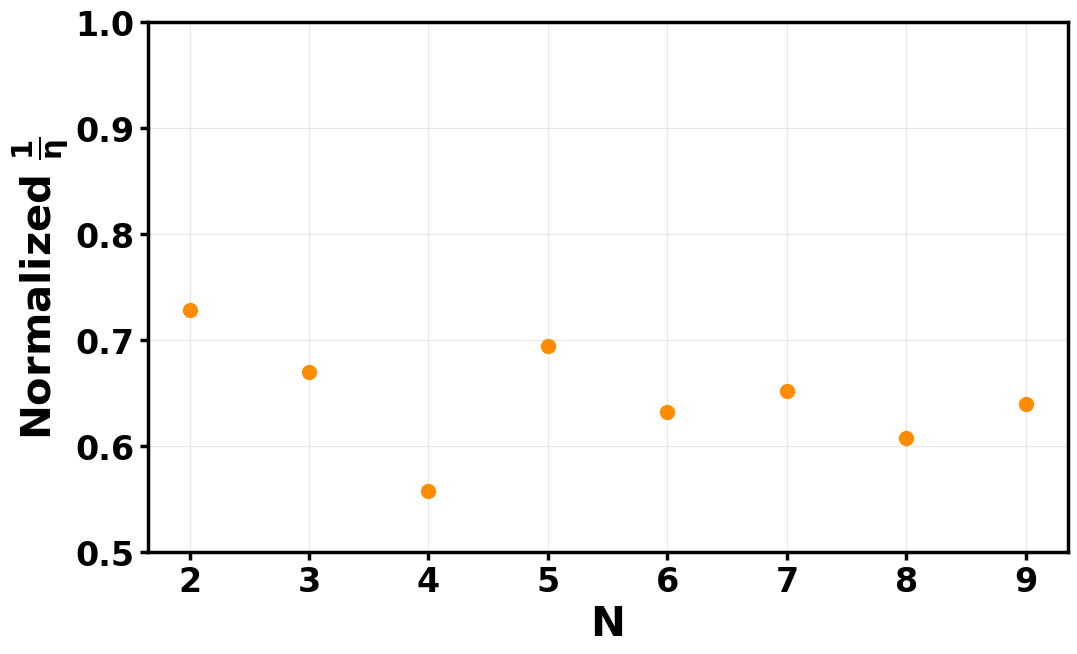

In [135]:
# --- Plot 2: tau ratio at optimal power ---
px = 1 / plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(1066 * px, 643 * px), layout='constrained')
ax.scatter(N_values_plot, opt_r, marker='o', color='#FF8C00', s=100, zorder=3)
ax.set_xlabel('N', fontsize=30, fontweight='bold')
ax.set_ylabel(r'Normalized $\mathbf{\frac{1}{\eta}}$', fontsize=30, fontweight='bold')
ax.set_ylim(0.5, 1)
style_ax(ax)
plt.show()

In [86]:
# Show tweezed winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

winners_N6_tweezed = run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq,
    P_opt_N6,
    w0,
    max_tweezed=1,
)

if winners_N6_tweezed:
    best_tweezed = winners_N6_tweezed[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Tweezed winner (best):", best_tweezed)
else:
    print("No tweezed winner returned for N =", N, "at P =", P_opt_N6)

N = 6 P_opt (W) = 0.00505149494949495
Tweezed winner (best): (2, (2, 0, 5, 4, 1, 3), 0.028782076634981894, 0.00505149494949495, array([ 0.02878208, -0.03080573,  0.02914011,  0.0326646 , -0.03719151,
        0.03972731]))


In [87]:
# Show untweezed winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

winners_N6_untweezed = run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq,
    P_opt_N6,
    w0,
)

if winners_N6_untweezed:
    best_untweezed = winners_N6_untweezed[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Untweezed winner (best):", best_untweezed)
else:
    print("No untweezed winner returned for N =", N, "at P =", P_opt_N6)

N = 6 P_opt (W) = 0.00505149494949495
Untweezed winner (best): (nan, (0, 5, 2, 1, 4, 3), 0.02284535017128783, 0.00505149494949495, array([ 0.02284535,  0.03402723, -0.02350233,  0.03040264,  0.03145738,
       -0.03588009]))


Top vals (tweezed): [0.02878208 0.03080573 0.02914011 0.0326646  0.03719151 0.03972731]

Tweezed case — tweezed ion: 2
  Ion 0 --> Mode 2
  Ion 1 --> Mode 0
  Ion 2 --> Mode 5 <-- tweezed
  Ion 3 --> Mode 4
  Ion 4 --> Mode 1
  Ion 5 --> Mode 3

Bottom vals (untweezed): [0.02284535 0.03402723 0.02350233 0.03040264 0.03145738 0.03588009]

Untweezed case — mode assignments:
  Ion 0 --> Mode 0
  Ion 1 --> Mode 5
  Ion 2 --> Mode 2
  Ion 3 --> Mode 1
  Ion 4 --> Mode 4
  Ion 5 --> Mode 3


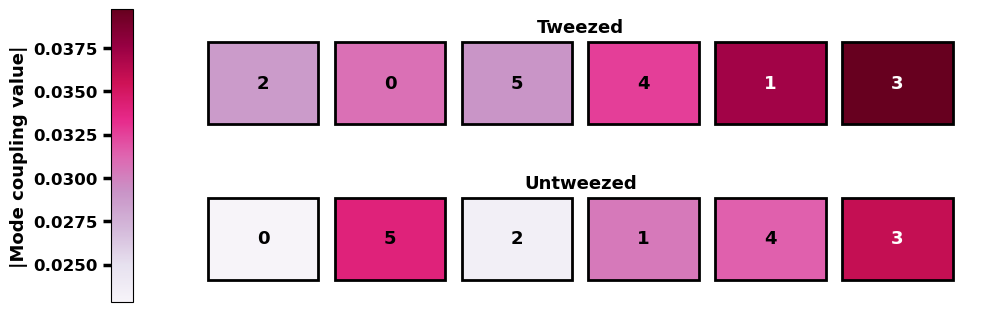

In [103]:
# Stack tweezed (top) and untweezed (bottom) winner visualizations with shared color scale

N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# ---------- Top: tweezed ----------
if 'winners_N6_tweezed' not in globals() or not winners_N6_tweezed:
    winners_N6_tweezed = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P_opt_N6,
        w0,
        max_tweezed=1,
    )

if not winners_N6_tweezed:
    raise ValueError("No tweezed winner returned for N=6.")

vals_top = np.abs(np.array(winners_N6_tweezed[0][4], dtype=float))
tweezed_ion = winners_N6_tweezed[0][0]
mode_map_top = winners_N6_tweezed[0][1]

print("Top vals (tweezed):", vals_top)
print(f"\nTweezed case — tweezed ion: {tweezed_ion}")
for ion_idx, mode_idx in enumerate(mode_map_top):
    marker = " <-- tweezed" if ion_idx == tweezed_ion else ""
    print(f"  Ion {ion_idx} --> Mode {mode_idx}{marker}")

# ---------- Bottom: untweezed ----------
if 'winners_N6_untweezed' not in globals() or not winners_N6_untweezed:
    winners_N6_untweezed = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P_opt_N6,
        w0,
    )

if not winners_N6_untweezed:
    raise ValueError("No untweezed winner returned for N=6.")

vals_bottom = np.abs(np.array(winners_N6_untweezed[0][4], dtype=float))
mode_map_bottom = winners_N6_untweezed[0][1]

print("\nBottom vals (untweezed):", vals_bottom)
print("\nUntweezed case — mode assignments:")
for ion_idx, mode_idx in enumerate(mode_map_bottom):
    print(f"  Ion {ion_idx} --> Mode {mode_idx}")

cmap = plt.get_cmap("PuRd")

# Shared normalization across BOTH sets
all_vals = np.concatenate([vals_top, vals_bottom])
norm = mcolors.Normalize(vmin=np.min(all_vals), vmax=np.max(all_vals))

# --- Layout parameters ---
step = 0.78
rect_width = 0.68
rect_height = 0.55
y_pos = 0.15
label_gap = 0.04

n_top = len(vals_top)
n_bottom = len(vals_bottom)
x_extent = (max(n_top, n_bottom) - 1) * step + rect_width
pad = 0.20
ylim_top = y_pos + rect_height + label_gap + 0.18

# --- Single figure ---
px = 1 / plt.rcParams['figure.dpi']
fig = plt.figure(figsize=(1066 * px, 3.8))

# Colorbar strip at x=0.14; tick labels extend left from there (~0.08 wide),
# so they occupy ~0.06–0.14; boxes start at 0.20.

# --- Top row (Tweezed) ---
ax_top = fig.add_axes([0.20, 0.51, 0.76, 0.36])
ax_top.set_xlim(-pad, x_extent + pad)
ax_top.set_ylim(0, ylim_top)
ax_top.axis('off')
ax_top.text(x_extent / 2, y_pos + rect_height + label_gap, 'Tweezed',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

for i, (val, mode) in enumerate(zip(vals_top, mode_map_top)):
    x_pos = i * step
    color = cmap(norm(val))
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height,
                          facecolor=color, edgecolor='black', linewidth=2)
    ax_top.add_patch(rect)
    text_color = 'white' if val > 0.035 else 'black'
    ax_top.text(x_pos + rect_width / 2, y_pos + rect_height / 2, str(mode),
                ha='center', va='center', fontsize=13, fontweight='bold', color=text_color)

# --- Bottom row (Untweezed) ---
ax_bottom = fig.add_axes([0.20, 0.10, 0.76, 0.36])
ax_bottom.set_xlim(-pad, x_extent + pad)
ax_bottom.set_ylim(0, ylim_top)
ax_bottom.axis('off')
ax_bottom.text(x_extent / 2, y_pos + rect_height + label_gap, 'Untweezed',
               ha='center', va='bottom', fontsize=13, fontweight='bold')

for i, (val, mode) in enumerate(zip(vals_bottom, mode_map_bottom)):
    x_pos = i * step
    color = cmap(norm(val))
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height,
                          facecolor=color, edgecolor='black', linewidth=2)
    ax_bottom.add_patch(rect)
    text_color = 'white' if val > 0.035 else 'black'
    ax_bottom.text(x_pos + rect_width / 2, y_pos + rect_height / 2, str(mode),
                   ha='center', va='center', fontsize=13, fontweight='bold', color=text_color)

# --- Vertical colorbar on the LEFT: ticks pointing left (outward) ---
cax = fig.add_axes([0.14, 0.10, 0.02, 0.77])
cb = mcolorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')
cb.set_label('|Mode coupling value|', fontsize=13, fontweight='bold')
cb.ax.tick_params(labelsize=12, width=2.5, length=6)
for tick_label in cb.ax.get_yticklabels():
    tick_label.set_fontweight('bold')

plt.show()

In [108]:
Ns_to_sweep = np.arange(3, 71)
f_rf_r = 3e6
f_rf_a_30 = 1e6
f_rf_r_30 = f_rf_a_30*0.77*30/np.sqrt(np.log(30))
f_rf_a = 200e3
P = 100e-3
w0 = 1e-6
N_test = 5
ueq_dict = {N:ion_spacing(N, f_rf_a * 2 * pi)[0] for N in Ns_to_sweep}
U = potential(omega_tweezer,linewidths,omega_res,P,w0)
physical_params_to_radial_mode_vectors(N_test, ueq_dict[N_test], [0], tweezer_wavelength, linewidths, omega_res, f_rf_a*2.0*pi, f_rf_r*2.0*pi, P, w0, m, U)

[(3009839.5334069594,
  array([-0.92377507, -0.3150764 , -0.17445251, -0.10940018, -0.07045857])),
 (2997221.4240275407,
  array([-0.25141752,  0.18269538,  0.38828081,  0.54067081,  0.67847234])),
 (2986233.4449758986,
  array([ 0.23394381, -0.48615397, -0.5200749 , -0.15980514,  0.64257997])),
 (2972915.1617832743,
  array([-0.15612018,  0.64815952, -0.06149422, -0.66435037,  0.33222397])),
 (2958243.5767673985,
  array([-0.06576958,  0.45923067, -0.73793285,  0.47833835, -0.10690689]))]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

result = tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    [5],
    f_rf_r,
    ueq_dict,
    P,
    w0,
    max_tweezed=1,
    qubit_lambda=729e-9
).iloc[1]

N = int(result["N"])
radial_modes = []
etas_radial = []

qubit_lambda = 729e-9
k = 2.0 * np.pi / qubit_lambda
eigvec_scale = k * np.sqrt(hbar / (2.0 * m))

for mode_idx in range(N):
    freq_col = f"Mode{mode_idx}_freq"
    eigvec_col = f"Mode{mode_idx}_eigvec"
    if freq_col not in result.index or eigvec_col not in result.index:
        continue
    freq = result[freq_col]
    if pd.isna(freq):
        continue
    omega_mode = 2.0 * np.pi * freq
    scale = eigvec_scale * np.sqrt(1.0 / omega_mode)
    raw_eigvec = np.asarray(result[eigvec_col], dtype=float).ravel() / scale
    etas_radial.append(np.abs(raw_eigvec))
    radial_modes.append(freq)

# --- parameters ---
fontsize       = 20
bold           = True
cell_scale     = (1, 1)
row_label_fmt  = "{freq_mhz:.4f}"
value_decimals = 4
fig_size_px    = (1330, 790)
colormap       = "PuRd"
font_color     = "auto"

n_modes = len(radial_modes)
N_ions  = len(etas_radial[0])

col_labels = ["$f_{{m}}$ (MHz)"] + [f"Ion {i+1}" for i in range(N_ions)]

purple_cmap = plt.get_cmap("Purples")
row_label_colors = [mcolors.to_hex(purple_cmap(0.3 + 0.6 * i / max(n_modes - 1, 1))) for i in range(n_modes)]

color_data = []
table_data = []
for i, freq in enumerate(radial_modes):
    color_vals = [f"{eta:.{value_decimals}f}" for eta in etas_radial[i]]
    color_data.append(color_vals)
    table_data.append([row_label_fmt.format(i=i, freq_mhz=freq / 1e6)] + [""] * len(color_vals))

all_values = np.abs(np.concatenate(etas_radial))
vmin = np.nanmin(all_values)
vmax = np.nanmax(all_values)

cmap = plt.get_cmap(colormap)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

def _contrast_color(rgba):
    r, g, b, *_ = rgba
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.5 else "white"

# Column widths matching plot_mode_table_from_results_test
fig_w_pts = (fig_size_px[0] / plt.rcParams["figure.dpi"]) * 72
ax_w_pts = fig_w_pts * 0.83
max_ion_chars = max(len(lbl) for lbl in col_labels[1:])
ion_col_width = (max_ion_chars * fontsize * 0.6 + fontsize) / ax_w_pts
freq_labels = [row[0] for row in table_data]
max_freq_chars = max(len(lbl) for lbl in freq_labels)
freq_col_width = (max_freq_chars * fontsize * 0.6 + 1.5 * fontsize) / ax_w_pts
total_col_width = freq_col_width + N_ions * ion_col_width

px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(fig_size_px[0] * px, fig_size_px[1] * px))
ax.set_position([0.01, 0.04, 0.83, 0.88])
ax.axis("off")

fw = "bold" if bold else "normal"

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="upper left",
    cellLoc="center",
    bbox=[0.0, 0.0, total_col_width, 0.96],
)
table.auto_set_font_size(False)
table.set_fontsize(fontsize)
table.scale(*cell_scale)

for r in range(n_modes + 1):
    table[r, 0].set_width(freq_col_width)
    for c in range(1, N_ions + 1):
        table[r, c].set_width(ion_col_width)

for key, cell in table.get_celld().items():
    cell.set_linewidth(2)
    cell.PAD = 0.02

for i, (row, color_row) in enumerate(zip(table_data, color_data), start=1):
    for j in range(1, len(row)):
        color = cmap(norm(abs(float(color_row[j - 1]))))
        table[i, j].set_facecolor(color)
        fc = _contrast_color(color) if font_color == "auto" else font_color
        table[i, j].set_text_props(color=fc, fontweight=fw)
    bg = row_label_colors[i - 1]
    table[i, 0].set_facecolor(bg)
    fc = _contrast_color(mcolors.to_rgba(bg)) if font_color == "auto" else font_color
    table[i, 0].set_text_props(color=fc, fontweight=fw)

for j in range(len(col_labels)):
    table[0, j].set_facecolor("white")
    table[0, j].set_text_props(fontweight=fw)
table[0, 1].set_facecolor("#61D836")

cbar_left = 0.01 + 0.83 * total_col_width + 0.01
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([cbar_left, 0.18, 0.015, 0.64])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("|Mode Coupling Value|", fontsize=fontsize, style="normal", weight="bold")
cbar.ax.tick_params(labelsize=fontsize + 4, width=2, length=6)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")

plt.show()